In [ ]:
Bài 1

Kết quả MSE trên tập Test:
 -> LSTM MSE: 0.19672
 -> RNN MSE: 0.08748


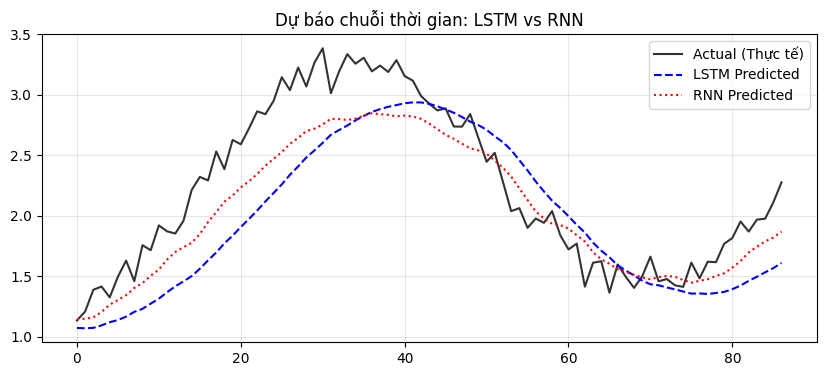

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42)
np.random.seed(42)


steps = 600
t = np.linspace(0, 50, steps)
series = np.sin(t) + 0.05 * t + 0.1 * np.random.randn(steps)


scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()


def create_windows(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return torch.FloatTensor(np.array(X)).unsqueeze(-1), torch.FloatTensor(np.array(y)).unsqueeze(-1)

seq_length = 20
X, y = create_windows(series_scaled, seq_length)

n_samples = len(X)
train_end = int(0.7 * n_samples)
val_end = int(0.85 * n_samples)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

class TimeSeriesModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1, cell_type='lstm'):
        super().__init__()
        self.cell_type = cell_type
        if cell_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        if self.cell_type == 'lstm':
            out, (h_n, c_n) = self.rnn(x)
        else:
            out, h_n = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_model(model, epochs=100, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    return model

lstm_model = train_model(TimeSeriesModel(cell_type='lstm'))
rnn_model = train_model(TimeSeriesModel(cell_type='rnn'))

lstm_model.eval()
rnn_model.eval()
with torch.no_grad():
    pred_lstm = lstm_model(X_test).numpy()
    pred_rnn = rnn_model(X_test).numpy()

actual_y = scaler.inverse_transform(y_test.numpy())
pred_lstm_unscaled = scaler.inverse_transform(pred_lstm)
pred_rnn_unscaled = scaler.inverse_transform(pred_rnn)

mse_lstm = np.mean((pred_lstm_unscaled - actual_y) ** 2)
mse_rnn = np.mean((pred_rnn_unscaled - actual_y) ** 2)

print(f"Kết quả MSE trên tập Test:\n -> LSTM MSE: {mse_lstm:.5f}\n -> RNN MSE: {mse_rnn:.5f}")

plt.figure(figsize=(10, 4))
plt.plot(actual_y, label='Actual (Thực tế)', color='black', alpha=0.8)
plt.plot(pred_lstm_unscaled, label='LSTM Predicted', linestyle='--', color='blue')
plt.plot(pred_rnn_unscaled, label='RNN Predicted', linestyle=':', color='red')
plt.title('Dự báo chuỗi thời gian: LSTM vs RNN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Bài 2


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.metrics import classification_report



raw_data = [
    ("điện thoại dùng rất mượt pin trâu", 1),
    ("sản phẩm tuyệt vời đóng gói cẩn thận", 1),
    ("giao hàng nhanh chất lượng ổn định", 1),

    ("máy lag kinh khủng pin tụt nhanh", 0),
    ("chất lượng kém không đáng tiền nên tránh", 0),
    ("giao sai màu sắc phục vụ tệ", 0)
]


raw_data = raw_data * 200


vocab = {"<pad>": 0, "<unk>": 1}

for sentence, _ in raw_data:
    for word in sentence.split():
        if word not in vocab:
            vocab[word] = len(vocab)

encoded_sequences = []
labels = []
lengths = []

for sentence, label in raw_data:
    tokens = [vocab.get(word, 1) for word in sentence.split()]

    encoded_sequences.append(
        torch.tensor(tokens, dtype=torch.long)
    )

    labels.append(label)
    lengths.append(len(tokens))


X_padded = pad_sequence(
    encoded_sequences,
    batch_first=True,
    padding_value=0
)

y_tensor = torch.tensor(labels, dtype=torch.long)
lengths_tensor = torch.tensor(lengths, dtype=torch.long)

# Train/Test split
train_size = int(0.8 * len(X_padded))

X_train = X_padded[:train_size]
X_test = X_padded[train_size:]

y_train = y_tensor[:train_size]
y_test = y_tensor[train_size:]

lens_train = lengths_tensor[:train_size]
lens_test = lengths_tensor[train_size:]


class BiSentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=32,
        hidden_dim=32,
        num_classes=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=2,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):

        embedded = self.embedding(x)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h_n, _) = self.lstm(packed)

        out_forward = h_n[-2]
        out_backward = h_n[-1]

        combined = torch.cat(
            [out_forward, out_backward],
            dim=1
        )

        return self.fc(combined)


model = BiSentimentLSTM(vocab_size=len(vocab))

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.005
)

for epoch in range(15):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train, lens_train)

    loss = criterion(logits, y_train)

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1} - Loss: {loss.item():.4f}")


model.eval()

with torch.no_grad():

    test_logits = model(X_test, lens_test)

    predictions = test_logits.argmax(dim=1).numpy()

print("\n--- BÁO CÁO KẾT QUẢ ---")

print(
    classification_report(
        y_test.numpy(),
        predictions,
        target_names=["Tiêu cực", "Tích cực"]
    )
)

Epoch 1 - Loss: 0.6973
Epoch 2 - Loss: 0.6580
Epoch 3 - Loss: 0.6159
Epoch 4 - Loss: 0.5614
Epoch 5 - Loss: 0.4879
Epoch 6 - Loss: 0.3959
Epoch 7 - Loss: 0.2913
Epoch 8 - Loss: 0.1899
Epoch 9 - Loss: 0.1082
Epoch 10 - Loss: 0.0544
Epoch 11 - Loss: 0.0265
Epoch 12 - Loss: 0.0131
Epoch 13 - Loss: 0.0069
Epoch 14 - Loss: 0.0038
Epoch 15 - Loss: 0.0022

--- BÁO CÁO KẾT QUẢ ---
              precision    recall  f1-score   support

    Tiêu cực       1.00      1.00      1.00       120
    Tích cực       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



Bài 3


In [6]:
import torch
import torch.nn as nn
import numpy as np

text_corpus = """Trăm năm trong cõi người ta, chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu, những điều trông thấy mà đau đớn lòng.
Thành tựu từ thuở tơ hồng, có tài mà cậy chi tài, chữ tài liền với chữ tai một vần."""

chars = sorted(list(set(text_corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

seq_length = 20
X_data, y_data = [], []

for i in range(len(text_corpus) - seq_length):
    in_seq = text_corpus[i : i + seq_length]
    out_char = text_corpus[i + seq_length]
    X_data.append([char_to_idx[ch] for ch in in_seq])
    y_data.append(char_to_idx[out_char])

X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.long)

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out[:, -1, :])

char_model = CharLSTM(vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(char_model.parameters(), lr=0.01)


for epoch in range(100):
    char_model.train()
    optimizer.zero_grad()
    outputs = char_model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

def generate_text(model, seed_str, gen_length=50, temperature=0.5):
    model.eval()
    current_input = [char_to_idx[ch] for ch in seed_str if ch in char_to_idx]
    if len(current_input) < seq_length:
        current_input = [char_to_idx[" "]] * (seq_length - len(current_input)) + current_input

    generated_text = seed_str

    with torch.no_grad():
        for _ in range(gen_length):
            inp = torch.tensor([current_input[-seq_length:]], dtype=torch.long)
            logits = model(inp).squeeze(0)

            probs = torch.softmax(logits / temperature, dim=0).numpy()

            next_idx = np.random.choice(len(probs), p=probs)
            next_char = idx_to_char[next_idx]

            generated_text += next_char
            current_input.append(next_idx)

    return generated_text


seed = "Trăm năm trong cõi"
print("\n--- KẾT QUẢ SINH VĂN BẢN TỰ ĐỘNG ---")
print("1. Với Temperature thấp (0.2 - Chặt chẽ, lặp lại):")
print(generate_text(char_model, seed, gen_length=40, temperature=0.2))
print("\n2. Với Temperature vừa phải (0.7 - Sáng tạo, mạch lạc tốt):")
print(generate_text(char_model, seed, gen_length=40, temperature=0.7))


--- KẾT QUẢ SINH VĂN BẢN TỰ ĐỘNG ---
1. Với Temperature thấp (0.2 - Chặt chẽ, lặp lại):
Trăm năm trong cõi dâu, những điều trông thấy mà đau đớn l

2. Với Temperature vừa phải (0.7 - Sáng tạo, mạch lạc tốt):
Trăm năm trong cõi ggưi ta, chữ tài chữ mệnh khéo là ghét 
